In [1]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# File path
file_path = '20250807_tahoe_lake1.txt'

# Read the data into a DataFrame
df = pd.read_csv(file_path)

# Convert 'time' column to datetime format
df['time'] = pd.to_datetime(df['time'], format='%y-%m-%d %H:%M:%S')

# Set 'time' column as the index
df.set_index('time', inplace=True)

# Localize the naive datetime to UTC first  
df.index = df.index.tz_localize('UTC').tz_convert('America/Los_Angeles')

# Ensure that longitude values are negative
df['lon'] = -df['lon']

df.tail()
# print(df['lat'].tail())s
# print(df['lon'].tail())

# Function to convert DD.MMmm to decimal degrees
# From ChatGPT
def convert_to_decimal_degrees(coord):
    degrees = int(coord)  # Extract degrees (integer part)
    minutes = abs(coord - degrees) * 100  # Extract the minutes
    decimal_degrees = abs(degrees) + minutes / 60  # Convert minutes to decimal and add to degrees
    return decimal_degrees if coord >= 0 else -decimal_degrees  # Keep the sign for negative coordinates

# Apply the conversion function to the lat and lon columns
df['lat_decimal'] = df['lat'].apply(convert_to_decimal_degrees)
df['lon_decimal'] = df['lon'].apply(convert_to_decimal_degrees)

print(df[['lat_decimal', 'lon_decimal']])

                           lat_decimal  lon_decimal
time                                               
2025-08-08 12:22:13-07:00     0.000000     0.000000
2025-08-08 12:22:14-07:00    38.802333  -120.143833
2025-08-08 12:22:15-07:00    38.802167  -120.143833
2025-08-08 12:22:17-07:00    38.802167  -120.143833
2025-08-08 12:22:18-07:00    38.802167  -120.143833
...                                ...          ...
2025-08-08 15:30:13-07:00    38.796167  -120.147000
2025-08-08 15:30:14-07:00    38.796167  -120.147000
2025-08-08 15:30:15-07:00    38.796167  -120.147000
2025-08-08 15:30:17-07:00    38.796167  -120.147000
2025-08-08 15:30:18-07:00    38.796167  -120.147000

[3906 rows x 2 columns]


In [2]:
# Create a Folium map centered at the first location
m = folium.Map(location=[df.iloc[0]['lat_decimal'], df.iloc[0]['lon_decimal']], zoom_start=16)

# Prepare the coordinates for the polyline
coordinates = df[['lat_decimal', 'lon_decimal']].values.tolist()

# Add a line connecting the points
folium.PolyLine(coordinates, color='blue', weight=2.5, opacity=1).add_to(m)

# Save map to an HTML file
m.save('20250807_lake1.html')


In [33]:
df.keys()

Index(['tempC', 'tempF', 'humidity', 'pressurehPa', 'fix', 'fixQual', 'lat',
       'latDir', 'lon', 'lonDir', 'speed', 'angle', 'alt', 'satNum', 'vBat',
       'lat_decimal', 'lon_decimal', 'speed_mph'],
      dtype='object')

In [28]:
print('Power-On Duration')
duration = df.index[-1]-df.index[0]
print(duration)

# Compute time differences
time_diffs = df.index.to_series().diff().dropna()

# Compute average duration
avg_duration = time_diffs.mean()

print(f"Platform Sampled at an average {avg_duration.total_seconds():.2f} Hz")


Power-On Duration
0 days 05:03:33
Platform Sampled at an average 1.35 Hz


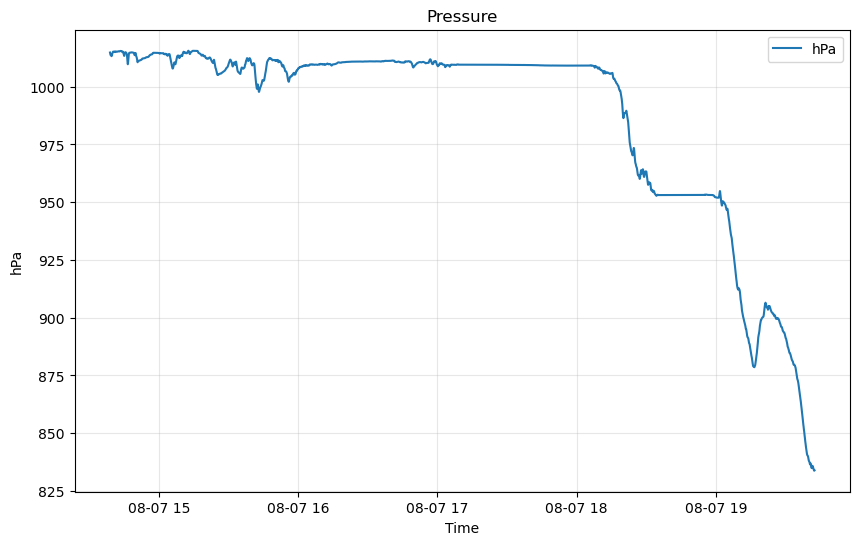

In [37]:
import matplotlib.pyplot as plt

# Convert m/s to mph
df['speed_mph'] = df['speed'] * 1.15  # 1 m/s = 2.23694 mph

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['pressurehPa'], label='hPa')
plt.xlabel('Time')
plt.ylabel('hPa')
plt.title('Pressure')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

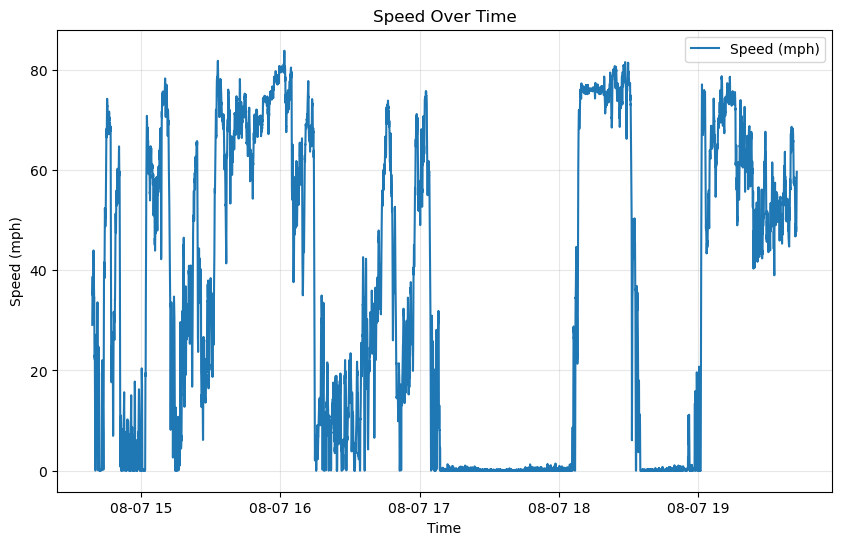

In [34]:
import matplotlib.pyplot as plt

# Convert m/s to mph
df['speed_mph'] = df['speed'] * 1.15  # 1 m/s = 2.23694 mph

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['speed_mph'], label='Speed (mph)')
plt.xlabel('Time')
plt.ylabel('Speed (mph)')
plt.title('Speed Over Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

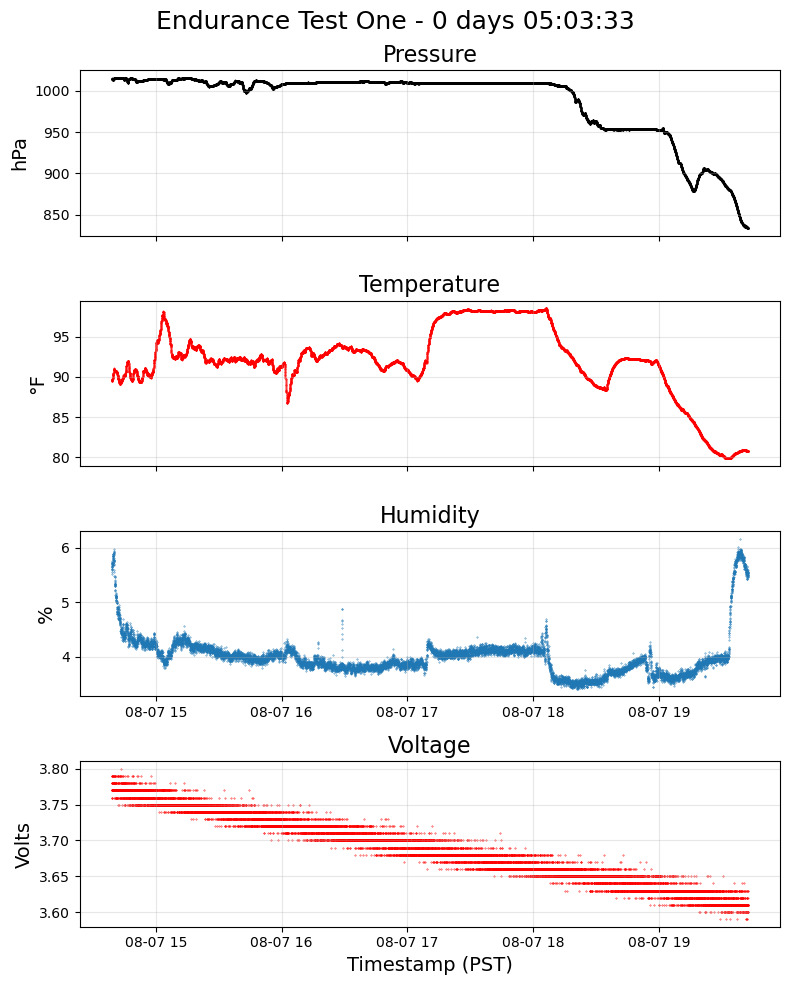

In [31]:
plt.figure(figsize=(8, 10))

size=0.1

plt.subplot(4, 1, 1)
plt.scatter(df.index, df['pressurehPa'],s=size,color='black',linewidth=1)
plt.title('Pressure', fontsize=16)
plt.ylabel('hPa', fontsize=14)
plt.grid(True, alpha=0.3)
plt.gca().set_xticklabels([])  # Remove x-tick labels for the first plot

plt.subplot(4, 1, 2)
plt.scatter(df.index, df['tempF'],s=size,color='red',linewidth=1)
plt.title('Temperature', fontsize=16)
plt.ylabel('°F', fontsize=14)
plt.grid(True, alpha=0.3)
plt.gca().set_xticklabels([])  # Remove x-tick labels for the second plot

plt.subplot(4, 1, 3)
plt.scatter(df.index, df['humidity'],s=size,linewidth=1)
plt.title('Humidity', fontsize=16)
plt.ylabel('%', fontsize=14)
# plt.xlabel('Timestamp (PST)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(4, 1, 4)
plt.scatter(df.index, df['vBat'],s=size,color='red')
plt.title('Voltage', fontsize=16)
plt.ylabel('Volts', fontsize=14)
plt.xlabel('Timestamp (PST)', fontsize=14)
plt.grid(True, alpha=0.3)

plt.suptitle(f'Endurance Test One - {duration}',fontsize=18)
plt.tight_layout()
# plt.savefig('20250313_endurance_test1.jpg',dpi=600)
plt.show()
